# Unicycle: Drop -> North -> Circle

This notebook runs a 10s simulation. The unicycle:
1. Falls to the ground.
2. Moves North (+Y) for 1 meter.
3. Enters an infinite circular motion.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.simulation.video_sim import VideoSim
from src.utils.config import load_config

In [7]:
config = str(ROOT / "config/unicycle_circle.yaml")

In [12]:
class UnicycleCircleSim(VideoSim):
    def __init__(self, config):
        super().__init__(config)
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model needs a free root joint (nq>=7, nv>=6).")

        self.start_z = 1.0
        self.north_speed = 1.0
        self.target_north = 1.0

        qw = np.cos(np.pi / 4)
        qz = np.sin(np.pi / 4)
        self.data.qpos[:7] = np.array([0.0, 0.0, self.start_z, qw, 0.0, 0.0, qz])
        self.data.qvel[:6] = 0.0

        self.landed = False
        self.reached_north = False
        self.circle_start_t = 0.0
        self.start_y = float(self.data.qpos[1])
        self.target_y = self.start_y + self.target_north

    def _loop_step(self, t: float, step: int):
        qpos = self.data.qpos
        qvel = self.data.qvel
        qacc = self.data.qacc

        if not self.landed and qpos[2] < 0.2 and abs(qvel[2]) < 0.01:
            self.landed = True

        if self.landed:
            if not self.reached_north:
                qvel[1] = self.north_speed
                if qpos[1] >= self.target_y:
                    qvel[:3] = 0.0
                    self.reached_north = True
                    self.circle_start_t = t
            else:
                omega = 2.0  # rad/s
                v = self.north_speed
                theta = np.pi/2 + omega * (t - self.circle_start_t)
                
                # Prescribe circular velocities
                qvel[0] = v * np.cos(theta)
                qvel[1] = v * np.sin(theta)
                qvel[2] = 0.0
                qvel[3] = 0.0
                qvel[4] = 0.0
                qvel[5] = omega
                
                # Explicitly override quaternion to guarantee upright posture
                qpos[3] = np.cos(theta/2.0)
                qpos[4] = 0.0
                qpos[5] = 0.0
                qpos[6] = np.sin(theta/2.0)

        self.logger.log({
            "x": float(qpos[0]),
            "y": float(qpos[1]),
            "z": float(qpos[2]),
            "vx": float(qvel[0]),
            "vy": float(qvel[1]),
            "vz": float(qvel[2]),
            "ax": float(qacc[0]),
            "ay": float(qacc[1]),
            "az": float(qacc[2]),
            "landed": bool(self.landed),
            "reached_north": bool(self.reached_north),
        })

In [13]:
import pandas as pd
pd.set_option('display.float_format', '{:.2e}'.format)

sim = UnicycleCircleSim(config)
sim.run()
df = sim.to_dataframe()
df.tail()

Simulation: 100%|██████████| 2000/2000 [00:01<00:00, 1836.81step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/unicycle_circle.mp4


,x,y,z,vx,vy,vz,ax,ay,az,landed,reached_north,t
1995,-7.01e-01,5.73e-01,1.50e-01,8.88e-01,-4.61e-01,0.00e+00,0.00e+00,0.00e+00,-9.81e+00,True,True,9.97e+00
1996,-6.96e-01,5.70e-01,1.50e-01,8.92e-01,-4.52e-01,0.00e+00,0.00e+00,0.00e+00,-9.81e+00,True,True,9.98e+00
1997,-6.92e-01,5.68e-01,1.51e-01,8.97e-01,-4.43e-01,0.00e+00,-2.08e+01,1.10e+01,2.20e+01,True,True,9.98e+00
1998,-6.88e-01,5.66e-01,1.50e-01,9.01e-01,-4.34e-01,0.00e+00,0.00e+00,0.00e+00,-9.81e+00,True,True,9.99e+00
1999,-6.83e-01,5.64e-01,1.50e-01,9.05e-01,-4.25e-01,0.00e+00,0.00e+00,2.43e-48,-9.81e+00,True,True,1.00e+01


In [14]:
from IPython.display import Video, Image, display, HTML
cfg = load_config(config)
video_path = Path(cfg['video_path'])
if not video_path.is_absolute():
    video_path = ROOT / video_path

if video_path.exists():
    display(Video(str(video_path), embed=True))
else:
    frames_dir = video_path.parent / (video_path.stem + '_frames')
    if frames_dir.exists():
        pngs = sorted(frames_dir.glob('*.png'))
        if pngs:
            display(Image(str(pngs[-1])))
            print(f'MP4 not available. Showing last frame from {frames_dir}')
    else:
        print('Video not found at', video_path)

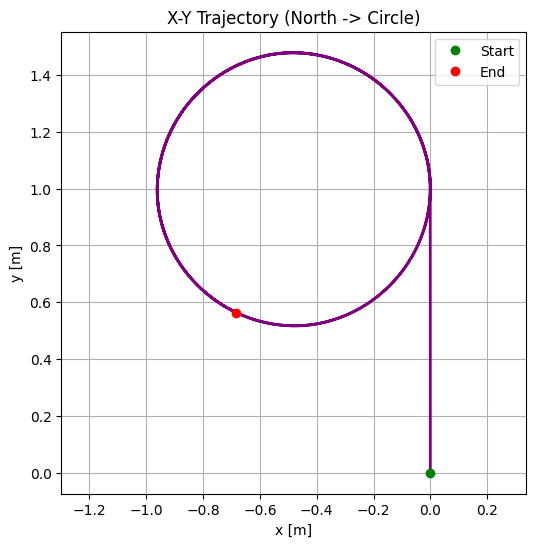

In [15]:
plt.figure(figsize=(6, 6))
plt.plot(df['x'], df['y'], color='purple', linewidth=2)
plt.plot(df['x'].iloc[0], df['y'].iloc[0], 'go', label='Start')
plt.plot(df['x'].iloc[-1], df['y'].iloc[-1], 'ro', label='End')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('X-Y Trajectory (North -> Circle)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()